# MG Boost Emulator Demo

This notebook demonstrates how to use the MG Boost Emulator to compute
the modified gravity boost to the matter power spectrum.

The emulator combines:
- A neural network (linear regime)
- A Gaussian Process (nonlinear regime)
- Smooth stitching across scales

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
import os

sys.path.append(os.path.abspath(".."))

from emulator.linear_nn import LinearBoostNN
from emulator.gp_emulator import NonlinearBoostGP
from emulator.stitching import BoostEmulator

In [6]:
MODEL_DIR = "../models/"

linear_model_path = MODEL_DIR + "linear_boost_nn.pt"

gp_full_path = MODEL_DIR + "gp_full_corrected.cpk"
pca_full_path = MODEL_DIR + "pca_full_corrected.cpk"

gp_bin5_path = MODEL_DIR + "gp_bin5.cpk"
pca_bin5_path = MODEL_DIR + "pca_bin5.cpk"
standardizer_bin5_path = MODEL_DIR + "standardizer_bin5.cpk"

k_path = MODEL_DIR + "cola_eg.txt"

Load Emulators

In [7]:
linear_emu = LinearBoostNN(linear_model_path)

gp_emu = NonlinearBoostGP(
    gp_full_path,
    pca_full_path,
    gp_bin5_path,
    pca_bin5_path,
    standardizer_bin5_path,
    k_path
)

emu = BoostEmulator(linear_emu, gp_emu)

/home/sankarshana/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.1.2 when using version 1.5.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/sankarshana/.local/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator GaussianProcessRegressor from version 1.1.2 when using version 1.5.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Define Cosmology

In [8]:
cosmo = {
    "Omega_m": 0.31,
    "Omega_b": 0.049,
    "h": 0.67,
    "n_s": 0.96,
    "A_s": 2.1e-9
}

mu = 1.05
eta = 1.0
bin_index = 2

In [9]:
zs = [0.0, 0.5, 1.0]

k, boost = emu.predict_boost(
    cosmo,
    mu=mu,
    eta=eta,
    bin_index=bin_index,
    zs=zs
)

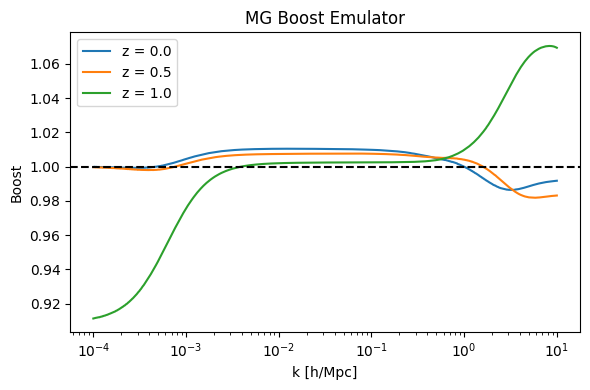

In [10]:
plt.figure(figsize=(6,4))

for i, z in enumerate(zs):
    plt.semilogx(k, boost[i], label=f"z = {z}")

plt.axhline(1.0, linestyle="--", color="black")

plt.xlabel("k [h/Mpc]")
plt.ylabel("Boost")
plt.title("MG Boost Emulator")

plt.legend()
plt.tight_layout()
plt.show()

Plot $P(k)$ for different $\mu$ 

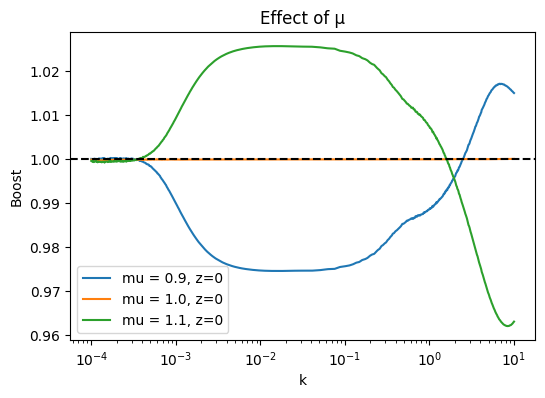

In [14]:
mus = [0.9, 1.0, 1.1]

plt.figure(figsize=(6,4))

for m in mus:
    k, boost = emu.predict_boost(
        cosmo,
        mu=m,
        eta=1.0,
        bin_index=4,
        zs=[0., 0.5, 1.0]
    )
    plt.semilogx(k, boost[0], label=f"mu = {m}, z=0")

plt.axhline(1.0, linestyle="--", color="black")

plt.xlabel("k")
plt.ylabel("Boost")
plt.legend()
plt.title("Effect of μ")
plt.show()